# **Exploring the Pokémon TCG market: how rarity, card category, and set era relate to price**

### **Research question**

This project explores how Pokémon TCG card prices relate to card rarity, supertype, subtype, set, and release year. The main goal is to see which characteristics appear most associated with higher market values.

### **Data sources**

*   Pokémon TCG API cards endpoint
*   Pokémon TCG API sets endpoint
*   Bulbapedia list of English Pokémon TCG expansions for optional set context





## **Reproducibility Note**

This notebook pulls live data from the Pokémon TCG API and saves cleaned CSV files and exported figures into local `data/` and `figures/` folders. Because the API is live, some pricing fields may change over time, so rerunning the notebook later may produce slightly different values.

### **Code**

**Imports & setup**

In [1]:
#I set up the main libraries here for pulling, cleaning, and plotting the data
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

**API setup**


In [2]:
#keep the API key optional so the notebook can still run without it
API_KEY = os.getenv("POKEMON_TCG_API_KEY")
BASE_URL = "https://api.pokemontcg.io/v2"

headers = {}
if API_KEY:
    headers["X-Api-Key"] = API_KEY

**API pull & pagination**

In [3]:
#pull multiple pages so I have enough rows for analysis
#this also makes the notebook easier to scale later if I want more cards
def fetch_cards(pages=4, page_size=250, sleep_time=0.25):
    all_cards = []

    for page in range(1, pages + 1):
        params = {
            "page": page,
            "pageSize": page_size,
            "orderBy": "set.releaseDate"
        }

        r = requests.get(f"{BASE_URL}/cards", headers=headers, params=params)
        r.raise_for_status()
        data = r.json()

        all_cards.extend(data["data"])
        print(f"page {page}: pulled {len(data['data'])} cards")
        time.sleep(sleep_time)

    return all_cards

cards_raw = fetch_cards(pages=4, page_size=250)
len(cards_raw)

page 1: pulled 250 cards
page 2: pulled 250 cards
page 3: pulled 250 cards
page 4: pulled 250 cards


1000

I pulled 1,000 cards total, which comfortably exceeds the minimum row requirement. This gives enough variation to compare price patterns across different card features.

**Pull sets**

In [4]:
#pull set-level data too because set name, series, and release date matter for the question
r = requests.get(f"{BASE_URL}/sets", headers=headers, params={"pageSize": 250})
r.raise_for_status()
sets_json = r.json()["data"]

sets_df = pd.DataFrame(sets_json)
sets_df.head()

,id,name,series,printedTotal,total,legalities,ptcgoCode,releaseDate,updatedAt,images
0,base1,Base,Base,102,102,{'unlimited': 'Legal'},BS,1999/01/09,2022/10/10 15:12:00,{'symbol': 'https://images.pokemontcg.io/base1...
1,base2,Jungle,Base,64,64,{'unlimited': 'Legal'},JU,1999/06/16,2020/08/14 09:35:00,{'symbol': 'https://images.pokemontcg.io/base2...
2,basep,Wizards Black Star Promos,Base,53,53,{'unlimited': 'Legal'},PR,1999/07/01,2020/08/14 09:35:00,{'symbol': 'https://images.pokemontcg.io/basep...
3,base3,Fossil,Base,62,62,{'unlimited': 'Legal'},FO,1999/10/10,2020/08/14 09:35:00,{'symbol': 'https://images.pokemontcg.io/base3...
4,base4,Base Set 2,Base,130,130,{'unlimited': 'Legal'},B2,2000/02/24,2022/10/10 15:12:00,{'symbol': 'https://images.pokemontcg.io/base4...


**Save raw files**

In [5]:
#I save the raw files so the project is easier to reproduce later
import os
os.makedirs("data", exist_ok=True)

pd.DataFrame(cards_raw).to_csv("data/cards_raw.csv", index=False)
sets_df.to_csv("data/sets.csv", index=False)

#also make a figures folder so my exported plots stay organized
os.makedirs("figures", exist_ok=True)

**Clean and flatten the card data**

In [6]:
#These helper functions make it easier to flatten the nested API response

def first_or_none(x):
    #I use this when a column is a list but I only want the first value
    if isinstance(x, list) and len(x) > 0:
        return x[0]
    return None

def join_list(x):
    #I use this when I want to keep the whole list as readable text
    if isinstance(x, list):
        return ", ".join(map(str, x))
    return None

def safe_get(d, keys):
    #This lets me safely pull nested values without crashing if something is missing
    current = d
    for key in keys:
        if isinstance(current, dict) and key in current:
            current = current[key]
        else:
            return None
    return current

**Price extraction**

In [7]:
#Price is nested and different cards store it under different finish types
#I pick one usable market price in a consistent order so I can compare cards more easily
def extract_tcgplayer_price(card):
    prices = safe_get(card, ["tcgplayer", "prices"])
    if not isinstance(prices, dict):
        return (None, None)

    order = [
        "holofoil",
        "reverseHolofoil",
        "normal",
        "1stEditionHolofoil",
        "1stEditionNormal"
    ]

    for kind in order:
        if kind in prices and isinstance(prices[kind], dict):
            market = prices[kind].get("market")
            if market is not None:
                return (market, kind)

    return (None, None)

One limitation of the price data is that cards do not all have one universal market value field. Because of this, I used a consistent rule to select one available TCGplayer market price per card. This simplifies the real market a little, but it makes the comparison possible.

**Build a flat dataframe**

In [8]:
#Here I flatten the card data so each row is one card and each column is a feature I can analyze
rows = []

for card in cards_raw:
    tcg_market, tcg_price_kind = extract_tcgplayer_price(card)

    row = {
        "card_id": card.get("id"),
        "name": card.get("name"),
        "supertype": card.get("supertype"),
        "subtype_primary": first_or_none(card.get("subtypes")),
        "subtypes_all": join_list(card.get("subtypes")),
        "type_primary": first_or_none(card.get("types")),
        "types_all": join_list(card.get("types")),
        "hp": card.get("hp"),
        "evolves_from": card.get("evolvesFrom"),
        "rarity": card.get("rarity"),
        "artist": card.get("artist"),
        "regulation_mark": card.get("regulationMark"),
        "national_pokedex_first": first_or_none(card.get("nationalPokedexNumbers")),
        "converted_retreat_cost": card.get("convertedRetreatCost"),
        "set_id": safe_get(card, ["set", "id"]),
        "set_name": safe_get(card, ["set", "name"]),
        "set_series": safe_get(card, ["set", "series"]),
        "set_release_date": safe_get(card, ["set", "releaseDate"]),
        "set_total": safe_get(card, ["set", "total"]),
        "set_printed_total": safe_get(card, ["set", "printedTotal"]),
        "tcgplayer_updated_at": safe_get(card, ["tcgplayer", "updatedAt"]),
        "price_usd": tcg_market,
        "price_kind": tcg_price_kind,
        "cardmarket_avg_sell_eur": safe_get(card, ["cardmarket", "prices", "averageSellPrice"]),
        "cardmarket_trend_eur": safe_get(card, ["cardmarket", "prices", "trendPrice"])
    }
    rows.append(row)

cards_df = pd.DataFrame(rows)
cards_df.head()

,card_id,name,supertype,subtype_primary,subtypes_all,type_primary,types_all,hp,evolves_from,rarity,artist,regulation_mark,national_pokedex_first,converted_retreat_cost,set_id,set_name,set_series,set_release_date,set_total,set_printed_total,tcgplayer_updated_at,price_usd,price_kind,cardmarket_avg_sell_eur,cardmarket_trend_eur
0,base1-1,Alakazam,Pokémon,Stage 2,Stage 2,Psychic,Psychic,80,Kadabra,Rare Holo,Ken Sugimori,None,65.0,3.0,base1,Base,Base,1999/01/09,102,102,2026/03/26,61.24,holofoil,139.99,197.00
1,base1-2,Blastoise,Pokémon,Stage 2,Stage 2,Water,Water,100,Wartortle,Rare Holo,Ken Sugimori,None,9.0,3.0,base1,Base,Base,1999/01/09,102,102,2026/03/26,183.48,holofoil,99.99,125.11
2,base1-3,Chansey,Pokémon,Basic,Basic,Colorless,Colorless,120,None,Rare Holo,Ken Sugimori,None,113.0,1.0,base1,Base,Base,1999/01/09,102,102,2026/03/26,49.17,holofoil,21.63,78.98
3,base1-4,Charizard,Pokémon,Stage 2,Stage 2,Fire,Fire,120,Charmeleon,Rare Holo,Mitsuhiro Arita,None,6.0,3.0,base1,Base,Base,1999/01/09,102,102,2026/03/26,494.23,holofoil,1496.67,1468.78
4,base1-5,Clefairy,Pokémon,Basic,Basic,Colorless,Colorless,40,None,Rare Holo,Ken Sugimori,None,35.0,1.0,base1,Base,Base,1999/01/09,102,102,2026/03/26,28.43,holofoil,29.16,30.63


**Data cleaning**

In [9]:
#convert the columns I want to compare numerically into actual numeric types
num_cols = [
    "hp",
    "national_pokedex_first",
    "converted_retreat_cost",
    "set_total",
    "set_printed_total",
    "price_usd",
    "cardmarket_avg_sell_eur",
    "cardmarket_trend_eur"
]

for col in num_cols:
    cards_df[col] = pd.to_numeric(cards_df[col], errors="coerce")

#parse release date so I can work with time more easily
cards_df["set_release_date"] = pd.to_datetime(cards_df["set_release_date"], errors="coerce")
cards_df["release_year"] = cards_df["set_release_date"].dt.year

#fill a few missing categorical fields so grouping is cleaner later
cards_df["rarity"] = cards_df["rarity"].fillna("Unknown")
cards_df["subtype_primary"] = cards_df["subtype_primary"].fillna("Unknown")
cards_df["type_primary"] = cards_df["type_primary"].fillna("Unknown")
cards_df["regulation_mark"] = cards_df["regulation_mark"].fillna("Unknown")
cards_df["supertype"] = cards_df["supertype"].fillna("Unknown")

cards_df.shape

(1000, 26)

After flattening and cleaning, the dataset contains 1,000 rows and 26 columns. This means it clearly meets the project requirement of having at least 12 features with mixed data types.

**Keep a strong analysis subset**

In [10]:
#For the main analysis, I keep cards that actually have usable price data
analysis_df = cards_df.dropna(subset=["price_usd", "rarity", "supertype", "release_year"]).copy()
analysis_df = analysis_df[analysis_df["price_usd"] > 0].copy()

analysis_df.shape
analysis_df.head()

,card_id,name,supertype,subtype_primary,subtypes_all,type_primary,types_all,hp,evolves_from,rarity,artist,regulation_mark,national_pokedex_first,converted_retreat_cost,set_id,set_name,set_series,set_release_date,set_total,set_printed_total,tcgplayer_updated_at,price_usd,price_kind,cardmarket_avg_sell_eur,cardmarket_trend_eur,release_year
0,base1-1,Alakazam,Pokémon,Stage 2,Stage 2,Psychic,Psychic,80.0,Kadabra,Rare Holo,Ken Sugimori,Unknown,65.0,3.0,base1,Base,Base,1999-01-09,102,102,2026/03/26,61.24,holofoil,139.99,197.00,1999
1,base1-2,Blastoise,Pokémon,Stage 2,Stage 2,Water,Water,100.0,Wartortle,Rare Holo,Ken Sugimori,Unknown,9.0,3.0,base1,Base,Base,1999-01-09,102,102,2026/03/26,183.48,holofoil,99.99,125.11,1999
2,base1-3,Chansey,Pokémon,Basic,Basic,Colorless,Colorless,120.0,None,Rare Holo,Ken Sugimori,Unknown,113.0,1.0,base1,Base,Base,1999-01-09,102,102,2026/03/26,49.17,holofoil,21.63,78.98,1999
3,base1-4,Charizard,Pokémon,Stage 2,Stage 2,Fire,Fire,120.0,Charmeleon,Rare Holo,Mitsuhiro Arita,Unknown,6.0,3.0,base1,Base,Base,1999-01-09,102,102,2026/03/26,494.23,holofoil,1496.67,1468.78,1999
4,base1-5,Clefairy,Pokémon,Basic,Basic,Colorless,Colorless,40.0,None,Rare Holo,Ken Sugimori,Unknown,35.0,1.0,base1,Base,Base,1999-01-09,102,102,2026/03/26,28.43,holofoil,29.16,30.63,1999


I created a smaller analysis subset because not every card in the API has complete pricing information. This makes the price-based comparisons cleaner and easier to interpret.

**Save cleaned file**

In [11]:
cards_df.to_csv("data/cards_clean.csv", index=False)

**Bulbapedia enrichment**

Bulbapedia’s English expansions page lists expansion names, release dates, and series groupings across Base, Neo, EX, Diamond & Pearl, Black & White, XY, Sun & Moon, Sword & Shield, Scarlet & Violet, and more. I used Bulbapedia’s list of English Pokémon TCG expansions as additionl context for set history. The API already gives set names and release dates, but this extra source helps connect the card data to the broader expansion timeline across different eras like Base, Neo, EX, XY, Sun & Moon, Sword & Shield, and Scarlet & Violet.

In [12]:
#request the Bulbapedia page directly first because the site blocks the default pandas request
#then pass the HTML into read_html so I can pull the tables from the page

import requests
import pandas as pd
from io import StringIO

bulba_url = "https://bulbapedia.bulbagarden.net/wiki/List_of_Pok%C3%A9mon_Trading_Card_Game_expansions"

headers = {
    "User-Agent": "Mozilla/5.0"
}

r = requests.get(bulba_url, headers=headers)
html = r.text

tables = pd.read_html(StringIO(html))
len(tables)

63

In [13]:
#loop through the scraped tables and keep the ones that actually look like expansion tables
#I only keep the columns I need for set name, release date, and abbreviation if it exists

expansion_tables = []

for t in tables:
    cols = [str(c) for c in t.columns]
    if any("Name of Expansion" in c for c in cols) and any("Release date" in c for c in cols):
        t.columns = cols
        name_col = [c for c in cols if "Name of Expansion" in c][0]
        date_col = [c for c in cols if "Release date" in c][0]

        keep_cols = [name_col, date_col]
        if any("Set abb." in c for c in cols):
            keep_cols.append([c for c in cols if "Set abb." in c][0])

        temp = t[keep_cols].copy()
        temp.columns = ["bulba_set_name", "bulba_release_date"] + (["bulba_abbrev"] if len(keep_cols) == 3 else [])
        expansion_tables.append(temp)

bulba_df = pd.concat(expansion_tables, ignore_index=True)

#convert the release date into datetime so it is easier to compare later if needed
bulba_df["bulba_release_date"] = pd.to_datetime(bulba_df["bulba_release_date"], errors="coerce")

#remove empty and duplicate rows to keep the scraped table cleaner
bulba_df = bulba_df.dropna(subset=["bulba_set_name"]).drop_duplicates()

bulba_df.head()

,bulba_set_name,bulba_release_date,bulba_abbrev
0,Base Set,1999-01-09,BS
1,Jungle,1999-06-16,JU
2,Fossil,1999-10-10,FO
3,Base Set 2,2000-02-24,B2
4,Team Rocket,2000-04-24,TR


In [14]:
#save the scraped expansion table so the project is easier to reproduce later
bulba_df.to_csv("data/bulbapedia_expansions.csv", index=False)

This Bulbapedia table is not the main dataset for the analysis, but it adds useful historical context for the set and era side of the project. It also shows that the project is drawing from more than one public source.

### **Quick inspection**

Before making graphs, I wanted to understand the overall structure of the dataset. This includes checking data types, looking at summary information, and measuring how much missing data appears in each column.

In [15]:
#check the dataframe info first so I can confirm the column types and see where missing values show up
cards_df.info()

#look at a quick summary table to understand the main columns at a glance
cards_df.describe(include="all").T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   card_id                  1000 non-null   object        
 1   name                     1000 non-null   object        
 2   supertype                1000 non-null   object        
 3   subtype_primary          1000 non-null   object        
 4   subtypes_all             868 non-null    object        
 5   type_primary             1000 non-null   object        
 6   types_all                800 non-null    object        
 7   hp                       802 non-null    float64       
 8   evolves_from             362 non-null    object        
 9   rarity                   1000 non-null   object        
 10  artist                   1000 non-null   object        
 11  regulation_mark          1000 non-null   object        
 12  national_pokedex_first   800 non-nu

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
card_id,1000,1000,neo3-38,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,1000,569,Pikachu,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supertype,1000,3,Pokémon,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtype_primary,1000,10,Basic,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtypes_all,868,9,Basic,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type_primary,1000,10,Unknown,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
types_all,800,9,Grass,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hp,802.0,NaN,NaN,NaN,61.097257,10.0,50.0,60.0,70.0,120.0,18.737773
evolves_from,362,175,Eevee,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rarity,1000,7,Uncommon,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This first inspection helps confirm that the dataframe includes a mix of numeric and categorical columns, which is important for the project requirements. It also helps show which fields will be more useful than others for the main analysis.

In [16]:
#calculate the share of missing values in each column so I can see which features are most incomplete
missing = cards_df.isna().mean().sort_values(ascending=False)
missing.head(15)

,0
evolves_from,0.638
price_kind,0.568
price_usd,0.568
converted_retreat_cost,0.326
national_pokedex_first,0.200
types_all,0.200
hp,0.198
subtypes_all,0.132
name,0.000
card_id,0.000


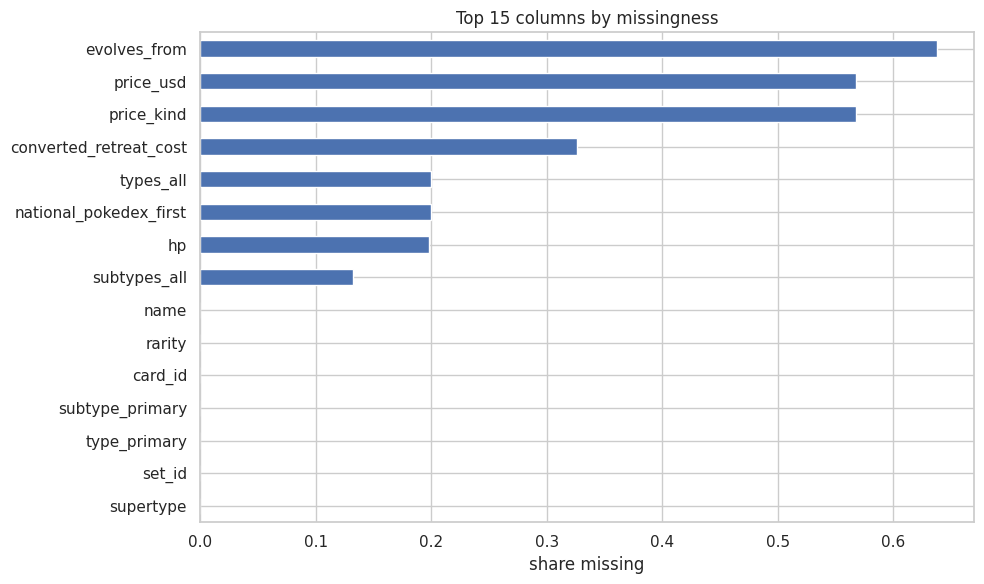

In [17]:
#plot the columns with the most missing data because this helps explain later limitations in the analysis
plt.figure(figsize=(10, 6))
missing.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 columns by missingness")
plt.xlabel("share missing")
plt.tight_layout()
plt.savefig("figures/missingness.png", dpi=200)
plt.show()


This missingness plot shows which variables are the least complete in the dataset. That matters because some parts of the card data, especially pricing and nested market fields, are not available for every card. This is one reason I created a smaller analysis subset later instead of using every single row for every graph.

**Summary statistics**

After the initial inspection, I looked at a few basic summary tables to get a better sense of the pricing subset. These quick summaries help show what kind of cards are actually included once I filter to rows with usable price data.

In [18]:
#start with a basic numeric summary for the main variables I care about most
analysis_df[["price_usd", "hp", "release_year"]].describe()

,price_usd,hp,release_year
count,432.000000,353.000000,432.000000
mean,65.450301,65.637394,1999.680556
std,128.871855,20.579777,0.653239
min,0.240000,10.000000,1999.000000
25%,1.307500,50.000000,1999.000000
50%,19.085000,70.000000,2000.000000
75%,79.735000,80.000000,2000.000000
max,1299.960000,120.000000,2001.000000


This summary gives a quick overview of the center and spread of the main numeric variables. It is especially useful for seeing how wide the price range is and how much variation there is in card release years.

In [19]:
#check the most common rarity values in the pricing subset
analysis_df["rarity"].value_counts().head(15)

,count
rarity,
Rare Holo,166
Uncommon,74
Common,74
Promo,51
Rare,36
Unknown,30
Rare Secret,1


This count table shows which rarity groups appear most often in the analysis subset. That is useful because some rarities may look more important simply because they appear more frequently, while others may be rare but much more expensive.

In [20]:
#also check the supertype counts so I know how the major card categories are represented
analysis_df["supertype"].value_counts()

,count
supertype,
Pokémon,352
Trainer,64
Energy,16


This shows how the dataset is divided across broad card categories like Pokémon, Trainer, and Energy. It helps give context for the later price-by-supertype plot.

In [21]:
#look at the most expensive cards directly so I can connect the bigger trends to actual examples
analysis_df.nlargest(10, "price_usd")[[
    "name", "set_name", "rarity", "supertype", "price_usd", "price_kind", "release_year"
]]

,name,set_name,rarity,supertype,price_usd,price_kind,release_year
766,Lugia,Neo Genesis,Rare Holo,Pokémon,1299.96,1stEditionHolofoil,2000
205,Pokémon Center,Wizards Black Star Promos,Promo,Trainer,1062.50,normal,1999
206,Lucky Stadium,Wizards Black Star Promos,Promo,Trainer,1050.33,normal,1999
414,Dark Charizard,Team Rocket,Rare Holo,Pokémon,680.37,1stEditionHolofoil,2000
974,Raikou,Neo Revelation,Rare Holo,Pokémon,500.00,1stEditionHolofoil,2001
3,Charizard,Base,Rare Holo,Pokémon,494.23,holofoil,1999
975,Suicune,Neo Revelation,Rare Holo,Pokémon,461.45,1stEditionHolofoil,2001
639,Rocket's Mewtwo,Gym Challenge,Rare Holo,Pokémon,450.96,1stEditionHolofoil,2000
880,Tyranitar,Neo Discovery,Rare Holo,Pokémon,400.49,1stEditionHolofoil,2001
413,Dark Blastoise,Team Rocket,Rare Holo,Pokémon,393.46,1stEditionHolofoil,2000


Looking at the most expensive cards helps show which combinations of rarity, set, and category appear near the top of the market. This is useful because it connects the broader statistical patterns to actual cards in the dataset.

### **Data Visualizations**

**Price distribution**

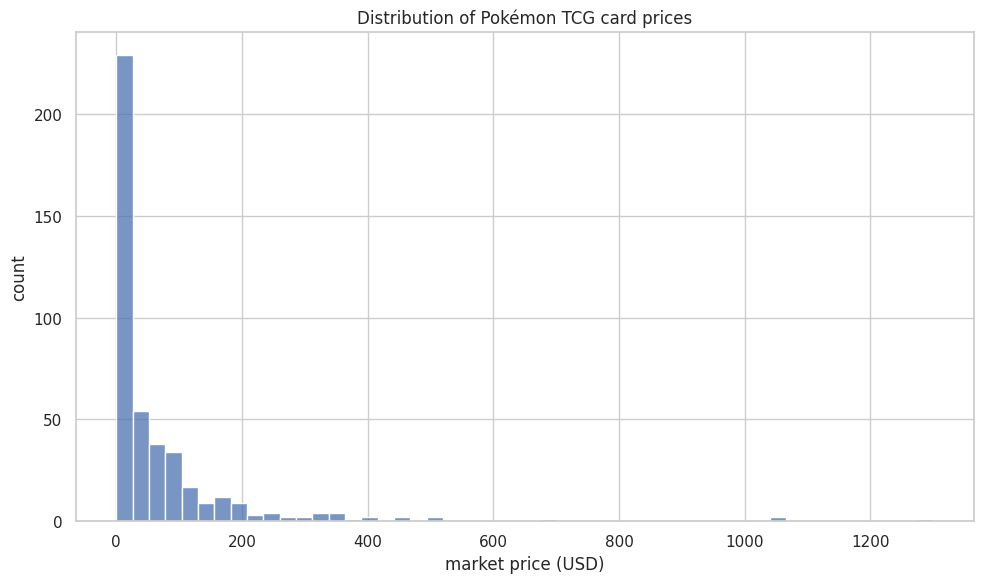

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(analysis_df["price_usd"], bins=50)
plt.title("Distribution of Pokémon TCG card prices")
plt.xlabel("market price (USD)")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("figures/price_distribution.png", dpi=200)
plt.show()

### Interpretation

This histogram shows that Pokémon TCG prices are highly right-skewed. Most cards in the dataset are clustered at relatively low prices, while a much smaller number of cards are much more expensive. This suggests that the market is uneven, with a few cards carrying much of the value.

**Log price distribution**

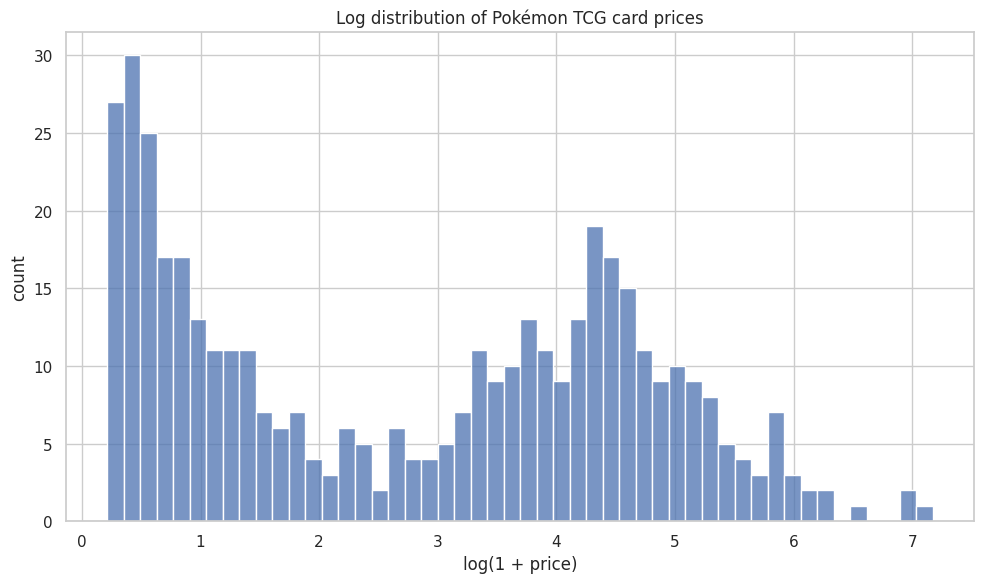

In [23]:
analysis_df["log_price"] = np.log1p(analysis_df["price_usd"])

plt.figure(figsize=(10, 6))
sns.histplot(analysis_df["log_price"], bins=50)
plt.title("Log distribution of Pokémon TCG card prices")
plt.xlabel("log(1 + price)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Interpretation

The log-transformed version makes the lower and middle part of the distribution easier to see. This confirms that the original distribution was strongly skewed and helps show that the majority of cards fall into a relatively low price range even when the extreme outliers are compressed.

**Price by rarity**

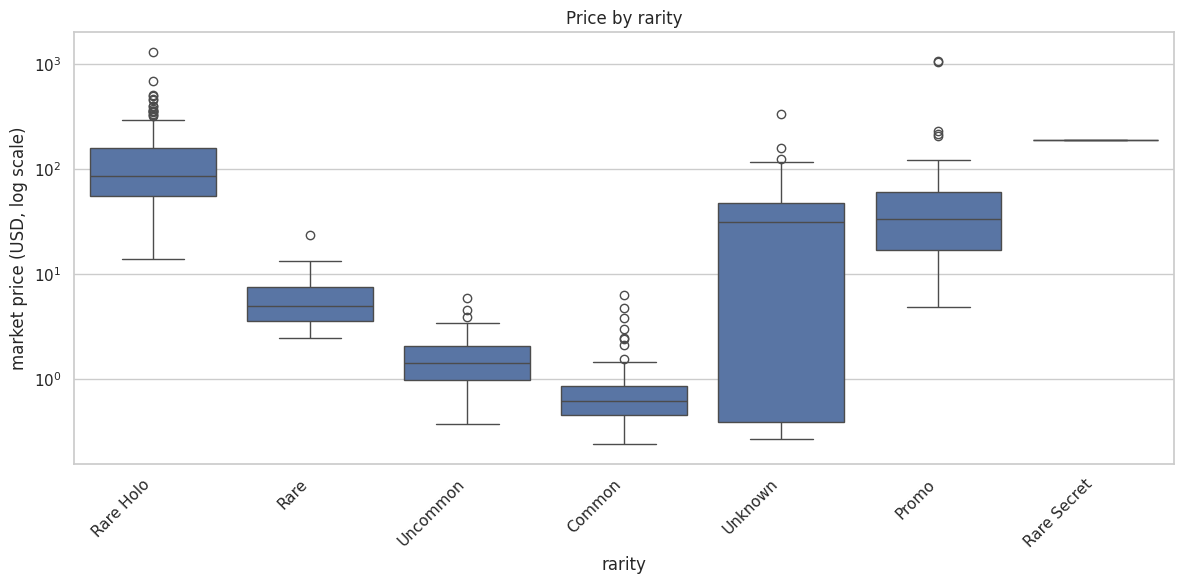

In [24]:
top_rarities = analysis_df["rarity"].value_counts().head(10).index
rarity_plot_df = analysis_df[analysis_df["rarity"].isin(top_rarities)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=rarity_plot_df, x="rarity", y="price_usd")
plt.yscale("log")
plt.title("Price by rarity")
plt.xlabel("rarity")
plt.ylabel("market price (USD, log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/price_by_rarity.png", dpi=200)
plt.show()

### Interpretation

This boxplot suggests that rarity is one of the strongest variables related to price. Some rarity groups have clearly higher median values and also a wider spread, which means rarity matters a lot, although it does not explain everything by itself. There is still variation within each rarity group, so other features like set and release context probably matter too.

**Average price by rarity**

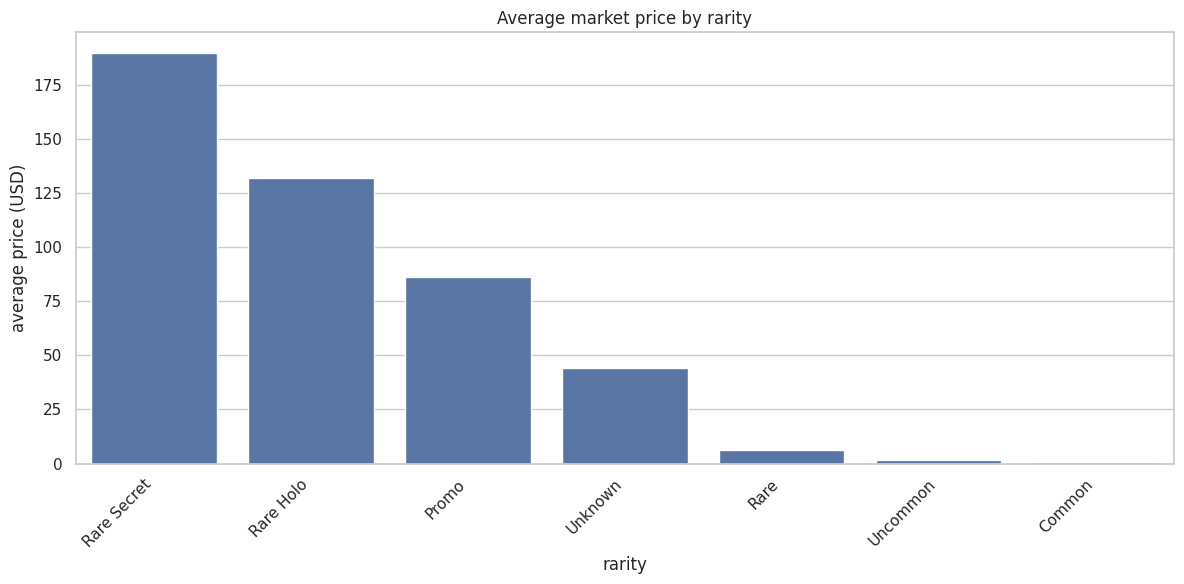

In [25]:
rarity_avg = (
    analysis_df.groupby("rarity", as_index=False)["price_usd"]
    .mean()
    .sort_values("price_usd", ascending=False)
    .head(12)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=rarity_avg, x="rarity", y="price_usd")
plt.title("Average market price by rarity")
plt.xlabel("rarity")
plt.ylabel("average price (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

This bar chart makes the rarity pattern easier to compare directly because it focuses on average price. Some rarities stand out much more than others, which supports the idea that scarcity and collector status are important drivers of value in the Pokémon TCG market.

**Price by supertype**

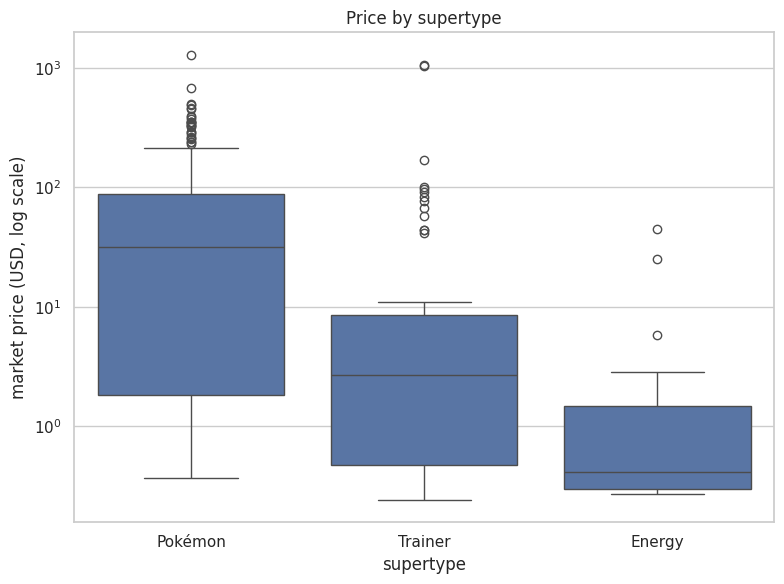

In [26]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=analysis_df, x="supertype", y="price_usd")
plt.yscale("log")
plt.title("Price by supertype")
plt.xlabel("supertype")
plt.ylabel("market price (USD, log scale)")
plt.tight_layout()
plt.savefig("figures/price_by_supertype.png", dpi=200)
plt.show()

### Interpretation

This plot shows that broad card category does have some relationship to price, but the differences are not as dramatic as the rarity-based differences. This suggests that while supertype may matter a little, it is probably not as strong a signal of value as collectibility features like rarity or set.

**Price over release year**

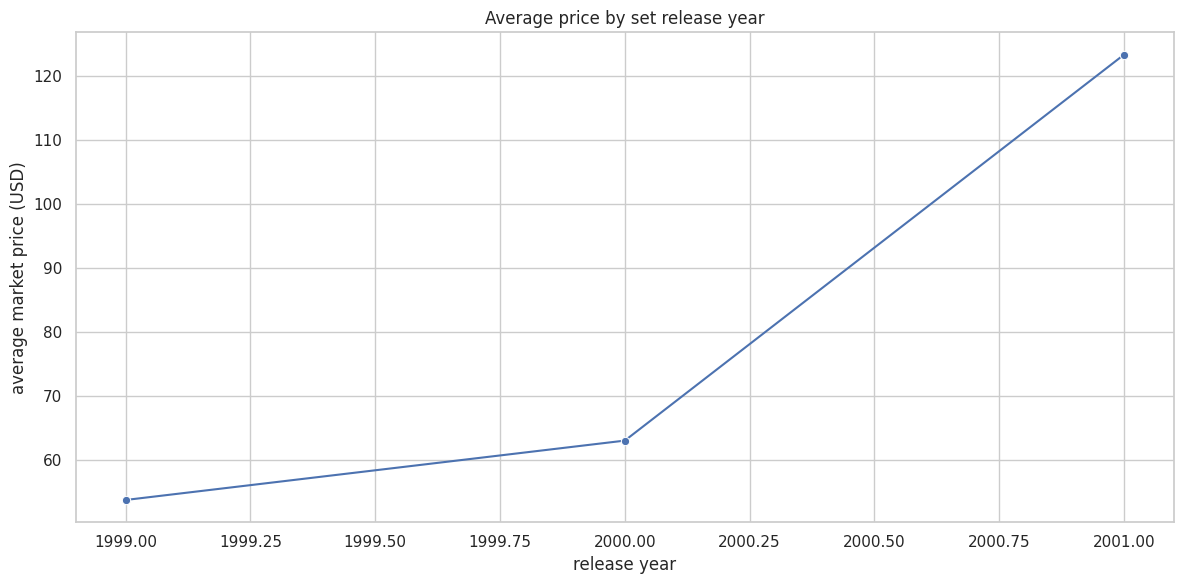

In [27]:
year_avg = (
    analysis_df.groupby("release_year", as_index=False)["price_usd"]
    .mean()
    .sort_values("release_year")
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=year_avg, x="release_year", y="price_usd", marker="o")
plt.title("Average price by set release year")
plt.xlabel("release year")
plt.ylabel("average market price (USD)")
plt.tight_layout()
plt.savefig("figures/price_by_release_year.png", dpi=200)
plt.show()

### Interpretation

The average price by release year suggests that older cards can have higher average value, but the pattern is not perfectly smooth. This means age matters, but not on its own. Set identity and card-specific demand still seem to affect value strongly even within the same general era.

**HP vs price**

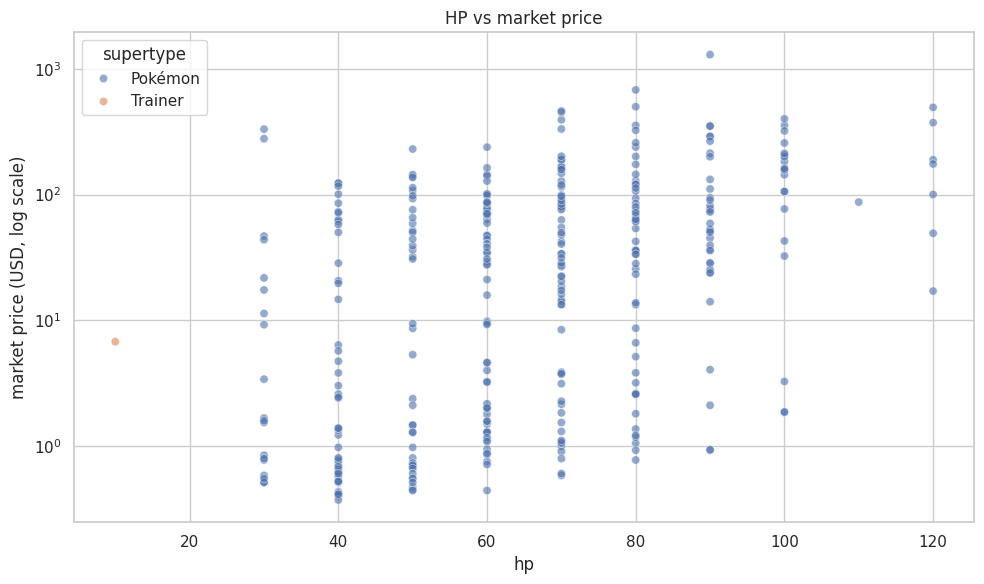

In [28]:
hp_df = analysis_df.dropna(subset=["hp"]).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=hp_df, x="hp", y="price_usd", hue="supertype", alpha=0.6)
plt.yscale("log")
plt.title("HP vs market price")
plt.xlabel("hp")
plt.ylabel("market price (USD, log scale)")
plt.tight_layout()
plt.show()

### Interpretation

This scatterplot does not show a strong direct relationship between HP and market price. Cards with high HP are not automatically expensive, and low-HP cards can still be valuable. This suggests that gameplay-style features are not the main thing driving collectible value in this dataset.

**Top sets by average price**

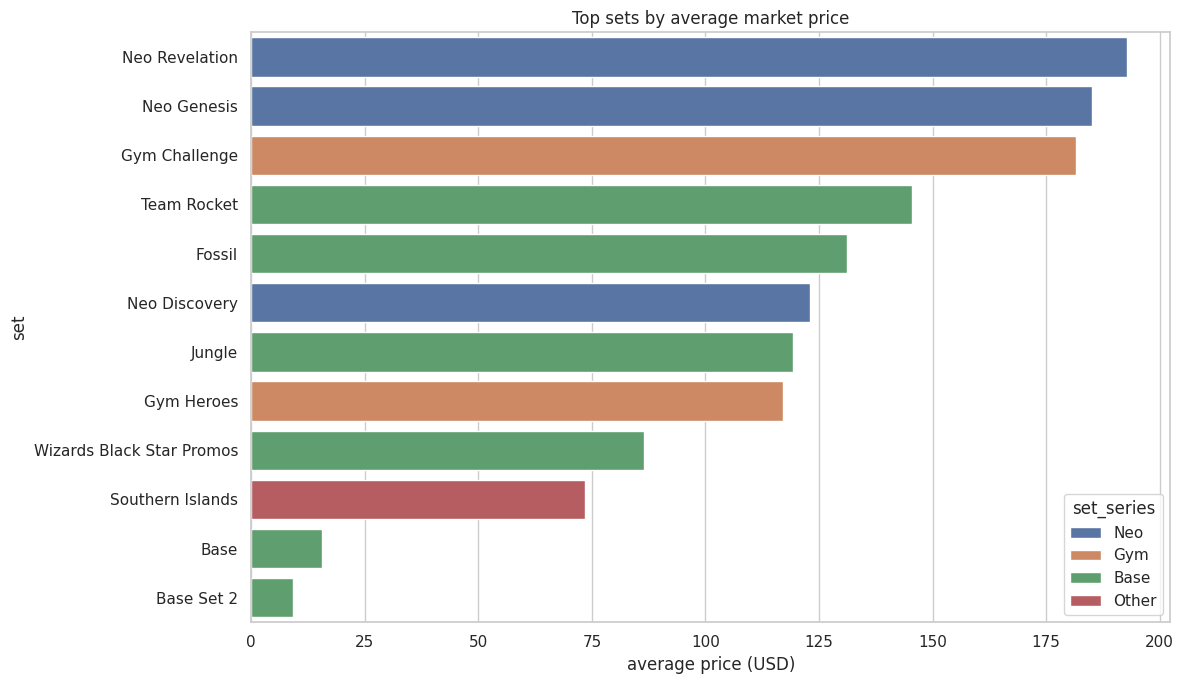

In [30]:
set_avg = (
    analysis_df.groupby(["set_name", "set_series"])["price_usd"]
    .agg(avg_price_usd="mean", n_cards="count")
    .reset_index()
)

set_avg = set_avg[set_avg["n_cards"] >= 5]
set_avg = set_avg.sort_values("avg_price_usd", ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=set_avg, x="avg_price_usd", y="set_name", hue="set_series", dodge=False)
plt.title("Top sets by average market price")
plt.xlabel("average price (USD)")
plt.ylabel("set")
plt.tight_layout()
plt.savefig("figures/top_sets_avg_price.png", dpi=200)
plt.show()

### Interpretation

This plot shows that some sets have noticeably higher average prices than others. That supports the idea that set identity plays an important role in the Pokémon TCG market. Some sets may be more valuable because of iconic chase cards, nostalgia, or stronger collector demand.

### **Statistical summaries**

In [31]:
#mean and median price by rarity
rarity_stats = (
    analysis_df.groupby("rarity")["price_usd"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

rarity_stats.head(15)

,count,mean,median,max
rarity,,,,
Rare Secret,1,189.930000,189.930,189.93
Rare Holo,166,132.138494,86.190,1299.96
Promo,51,86.458235,33.660,1062.50
Unknown,30,44.296000,30.975,331.62
Rare,36,6.117778,4.915,23.71
Uncommon,74,1.651351,1.430,5.85
Common,74,0.931351,0.610,6.34


This table reinforces the boxplot result by showing that some rarity groups have much higher mean and median prices than others. The gap between mean and median in some groups also suggests the presence of expensive outliers.

In [32]:
#mean and median price by supertype
supertype_stats = (
    analysis_df.groupby("supertype")["price_usd"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

supertype_stats

,count,mean,median,max
supertype,,,,
Pokémon,352,71.219347,31.640,1299.96
Trainer,64,48.767344,2.675,1062.50
Energy,16,5.263125,0.415,45.27


This table shows that supertype differences exist, but they are less dramatic than rarity differences. That makes supertype useful, but not as central to the pricing story.

In [33]:
#correlation among numeric fields
analysis_df[["price_usd", "hp", "set_total", "set_printed_total", "release_year"]].corr()

,price_usd,hp,set_total,set_printed_total,release_year
price_usd,1.000000,0.339753,-0.184957,-0.187100,0.130382
hp,0.339753,1.000000,0.067926,0.066718,0.129006
set_total,-0.184957,0.067926,1.000000,0.999932,0.094873
set_printed_total,-0.187100,0.066718,0.999932,1.000000,0.090300
release_year,0.130382,0.129006,0.094873,0.090300,1.000000


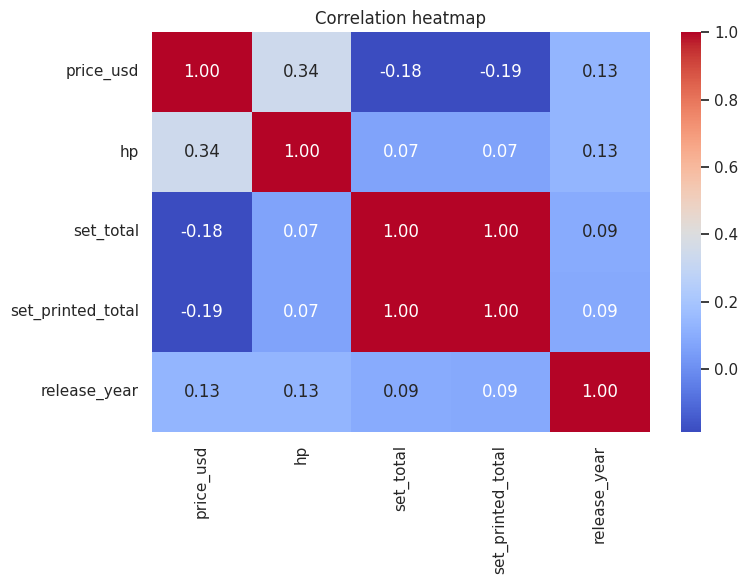

In [35]:
#I use a correlation heatmap here to quickly check whether the main numeric variables move together
#This helps me see if price has any clear linear relationship with things like HP, set size, or release year

plt.figure(figsize=(8, 6))
sns.heatmap(
    analysis_df[["price_usd", "hp", "set_total", "set_printed_total", "release_year"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap shows that the numeric variables in this dataset do not have especially strong linear relationships with price. In particular, HP does not appear strongly correlated with price. This supports the broader pattern in the earlier graphs that collectible features seem to matter more than simple gameplay or size-based numeric variables.

## **Key findings**
1. Card price is highly skewed, with many lower-priced cards and a much smaller number of expensive outliers.  
2. Rarity appears to be one of the clearest variables associated with higher price.  
3. Some sets and release eras have noticeably higher average prices, which suggests that historical and collector context matter.  
4. Broad card category shows some differences, but not as strongly as rarity and set identity.  
5. Gameplay-oriented variables like HP do not show a strong direct relationship with market price.  



## **Limitations**
	•	Not every card has market-price data, so the pricing subset is smaller than the full card dataset.
	•	Different finish types store price in different subfields, so choosing one “best” price requires a simplification.
	•	Market prices change over time, and the API only reflects the latest available updates.
	•	Some card features are missing more often in older cards.
	•	This is exploratory analysis, so it shows patterns, not causal relationships.

## **Conclusion**

This project asked which Pokémon TCG card characteristics seem most associated with higher market prices. Based on the exploratory analysis, the clearest answer is that rarity, set identity, and release context appear much more strongly related to price than gameplay-oriented features like HP. Overall, the results suggest that Pokémon TCG prices are shaped more by collectibility than by battle usefulness.